<a href="https://colab.research.google.com/github/weleba77/machine-Leaning-/blob/main/fcc_bikes_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler
import copy
import seaborn as sns
import tensorflow as tf
from sklearn.linear_model import LinearRegression

In [9]:
dataset_coln = [
    "Rented Bike Count",
    "Hour",
    "Temperature",
    "Humidity",
    "Wind speed",
    "Visibility",
    "Dew point temperature",
    "Solar Radiation",
    "Rainfall",
    "Snowfall",
    "Functioning Day"
]
df = pd.read_csv("SeoulBikeData.csv").drop(['Date', 'Seasons','Holiday'], axis=1)

In [ ]:
df.columns = dataset_coln
df['Functioning Day']= (df['Functioning Day']== 'Yes').astype(int)
df = df[df['Hour']==12]
df=df.drop(['Hour'], axis =1)

In [20]:
df.head()

,Rented Bike Count,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Functioning Day
12,449,1.7,23,1.4,2000,-17.2,1.11,0.0,0.0,0
36,479,4.3,41,1.3,1666,-7.8,1.09,0.0,0.0,0
60,333,5.8,85,1.7,349,3.4,0.43,0.0,0.0,0
84,393,-0.3,38,4.8,1823,-12.9,1.11,0.0,0.0,0
108,321,-2.3,25,0.0,1962,-19.7,0.00,0.0,0.0,0


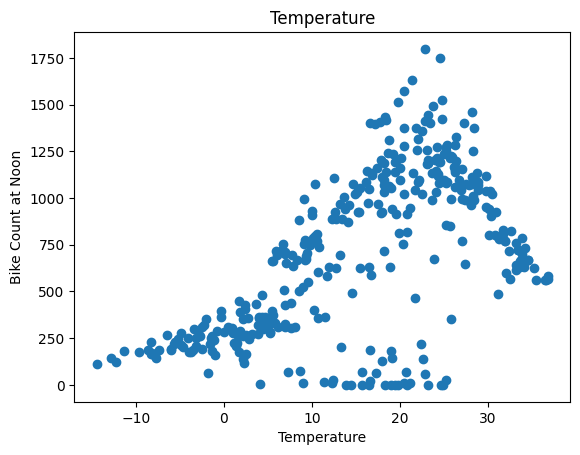

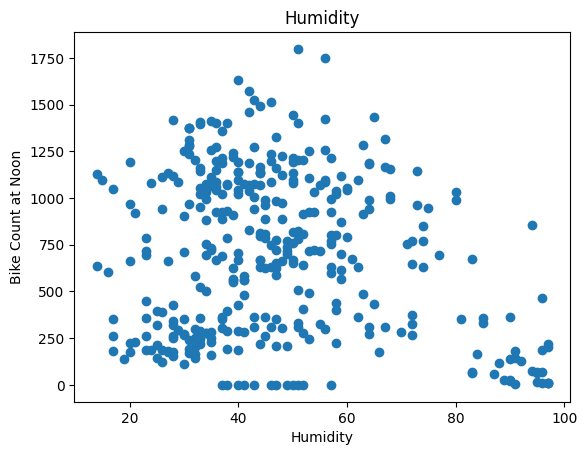

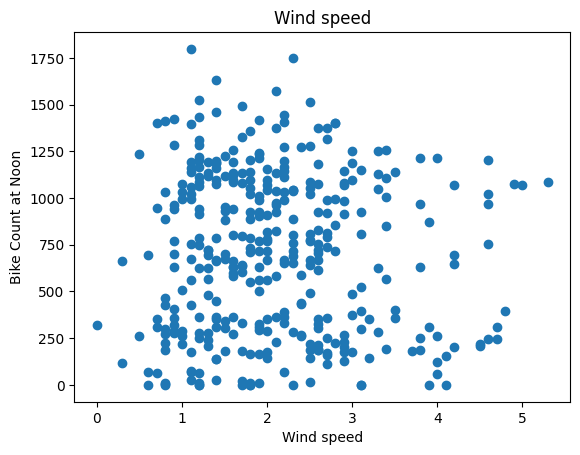

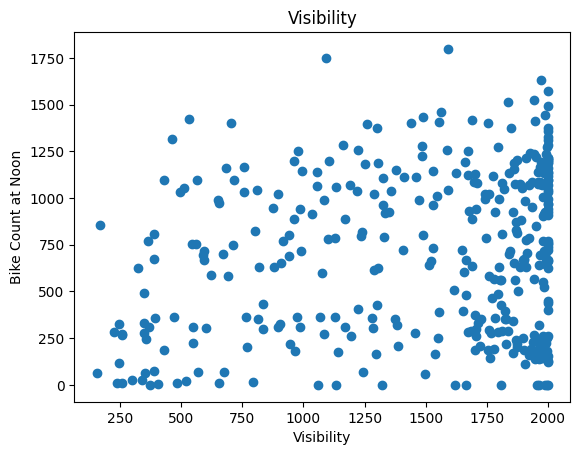

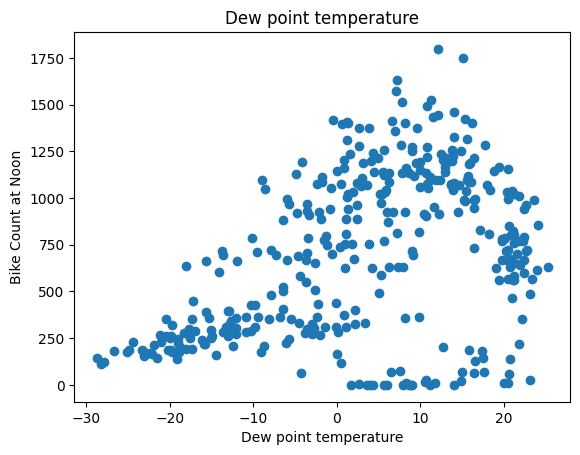

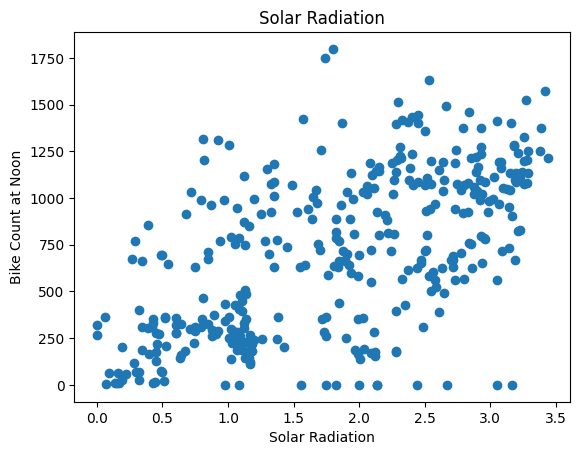

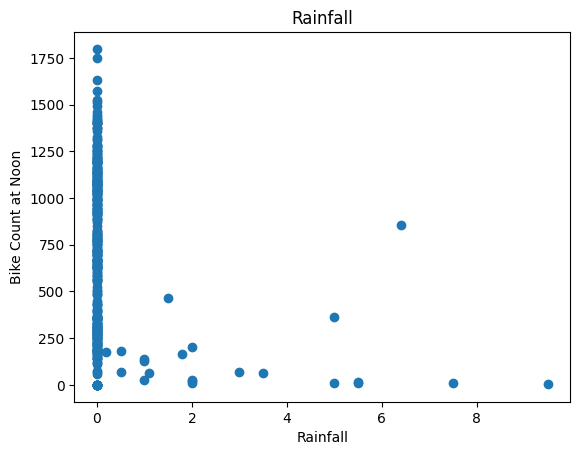

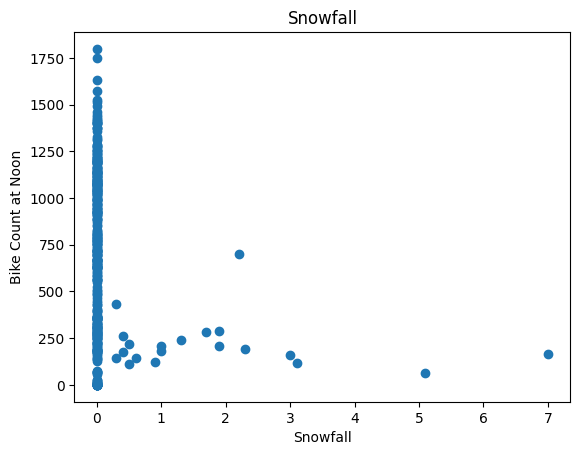

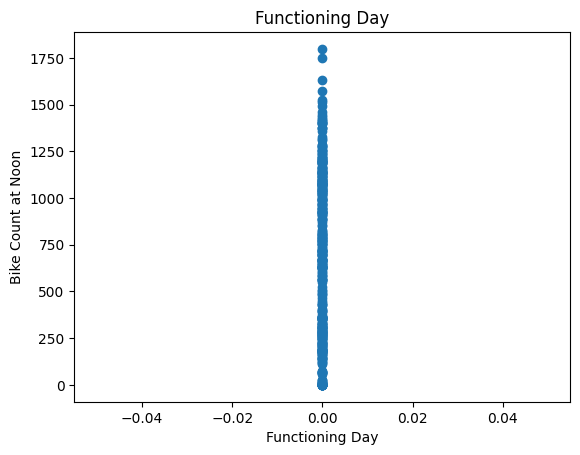

In [21]:
for label in df.columns[1:]:
  plt.scatter(df[label],df['Rented Bike Count'])
  plt.title(label)
  plt.ylabel('Bike Count at Noon')
  plt.xlabel(label)
  plt.show()

In [22]:
df= df.drop(['Visibility','Wind speed',"Functioning Day",], axis =1)

In [23]:
df.head()

,Rented Bike Count,Temperature,Humidity,Dew point temperature,Solar Radiation,Rainfall,Snowfall
12,449,1.7,23,-17.2,1.11,0.0,0.0
36,479,4.3,41,-7.8,1.09,0.0,0.0
60,333,5.8,85,3.4,0.43,0.0,0.0
84,393,-0.3,38,-12.9,1.11,0.0,0.0
108,321,-2.3,25,-19.7,0.00,0.0,0.0


Train/vaild/test **Datase**

In [26]:
train, valid, test = np.split(df.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))])

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [28]:
def get_xy(dataframe, y_label, x_label=None):
    dataframe = copy.deepcopy(dataframe)

    if x_label is None:
        x = dataframe[[c for c in dataframe.columns if c != y_label]].values
    else:
        if len(x_label) == 1:
            x = dataframe[x_label[0]].values.reshape(-1, 1)
        else:
            x = dataframe[x_label].values

    y = dataframe[y_label].values.reshape(-1, 1)

    data = np.hstack((x, y))

    return data, x, y

In [55]:
_, x_train_temp, y_train_temp = get_xy(train, 'Rented Bike Count', x_label=['Temperature'])
_, x_valid_temp, y_valid_temp = get_xy(valid, 'Rented Bike Count', x_label=['Temperature'])
_, x_test_temp, y_test_temp = get_xy(test, 'Rented Bike Count', x_label=['Temperature'])

In [31]:
x_train_temp


array([[ 15.5],
       [ 21.5],
       [  9. ],
       [ 30.2],
       [ 28.4],
       [  5.3],
       [ 13.8],
       [ 20.8],
       [  8.6],
       [ 19.1],
       [ 22.5],
       [ 23.7],
       [  9. ],
       [ 20.5],
       [ 22.9],
       [  2.2],
       [ -7.8],
       [ 18. ],
       [ 23.9],
       [ -8.6],
       [  9.3],
       [ 16.5],
       [  8.5],
       [ 12.8],
       [  6.2],
       [ 23.2],
       [  2.4],
       [ -1.6],
       [ 18. ],
       [ 25. ],
       [ -3.5],
       [ 26.4],
       [ 23.1],
       [ 12.4],
       [ 22.1],
       [ 12.6],
       [ -8.2],
       [ 14.7],
       [ 25.2],
       [  2.4],
       [ 25.7],
       [ 10.4],
       [ 10.4],
       [ 21.1],
       [ -3.2],
       [ -2.7],
       [ -2.9],
       [  4.7],
       [ 19.8],
       [ 26.1],
       [ 16.8],
       [ 22.5],
       [ 10. ],
       [ 13.2],
       [ 18.7],
       [ -1.3],
       [ 27. ],
       [ 27.4],
       [ 30.9],
       [ 17.5],
       [ 14.5],
       [ 25.8],
       [

In [56]:
temp_reg = LinearRegression()
temp_reg.fit(x_train_temp,y_train_temp)

LinearRegression()

In [35]:
print(temp_reg.coef_, temp_reg.intercept_)

[[21.3054953]] [376.85604073]


In [57]:
temp_reg.score(x_test_temp,y_test_temp)

0.2748518003619337

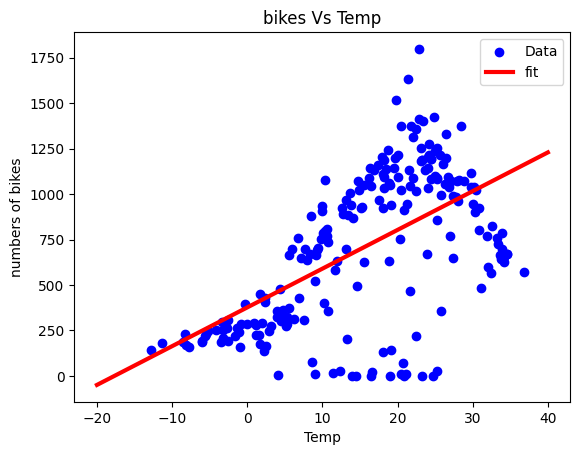

In [58]:
plt.scatter(x_train_temp, y_train_temp,label='Data', color='blue')
x= tf.linspace(-20, 40,100)
plt.plot(x, temp_reg.predict(np.array(x).reshape(-1,1)), label = 'fit', color ='red', linewidth = 3)
plt.legend()
plt.title('bikes Vs Temp')
plt.ylabel('numbers of bikes')
plt.xlabel('Temp')
plt.show()

Index(['Rented Bike Count', 'Temperature', 'Humidity', 'Dew point temperature',
       'Solar Radiation', 'Rainfall', 'Snowfall'],
      dtype='object')

In [47]:
_, x_train_all, y_train_all = get_xy(train, 'Rented Bike Count', x_label=df.columns[1:])
_, x_valid_all, y_valid_all = get_xy(valid, 'Rented Bike Count', x_label=df.columns[1:])
_, x_test_all, y_test_all = get_xy(test, 'Rented Bike Count', x_label=df.columns[1:])

In [48]:
all_reg = LinearRegression()
all_reg.fit(x_train_all, y_train_all)

LinearRegression()

In [50]:
all_reg.score(x_test_all,y_test_all)

0.3860487672290174

Regresssion with Neural Net

In [59]:
import tensorflow as tf

temp_normalizer = tf.keras.layers.Normalization(axis=None)
temp_normalizer.adapt(x_train_temp.reshape(-1, 1))

In [60]:
temp_nn_model = tf.keras.Sequential([
    temp_normalizer,
    tf.keras.layers.Dense(1)
])

In [62]:
def plot_loss(history):
  plt.plot(history.history['loss'], label = 'loss')
  plt.plot(history.history['val_loss'], label = 'val_loss')
  plt.xlabel('Epoch')
  plt.ylabel('MSE')
  plt.legend()
  plt.grid(True)
  plt.show()

In [66]:
temp_nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='mean_squared_error'

)

In [69]:
x_train = x_train_temp.reshape(-1)
x_valid = x_valid_temp.reshape(-1)

In [71]:
temp_nn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),   # 1 feature, BUT 2D format
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1)
])

In [73]:
temp_nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error'
)

In [74]:
history = temp_nn_model.fit(
    x_train,
    y_train_temp,
    epochs=1000,
    validation_data=(x_valid, y_valid_temp),
    verbose=0
)

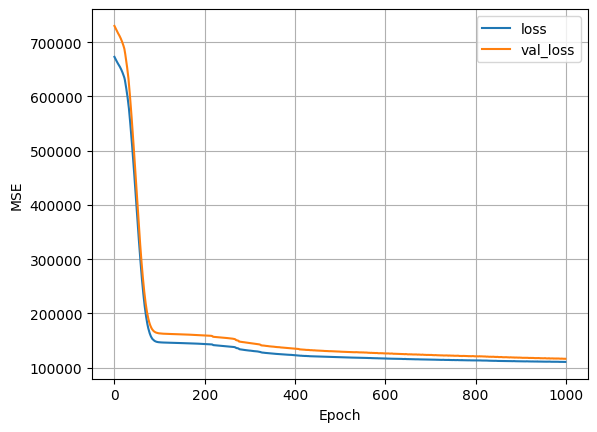

In [75]:
plot_loss(history)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


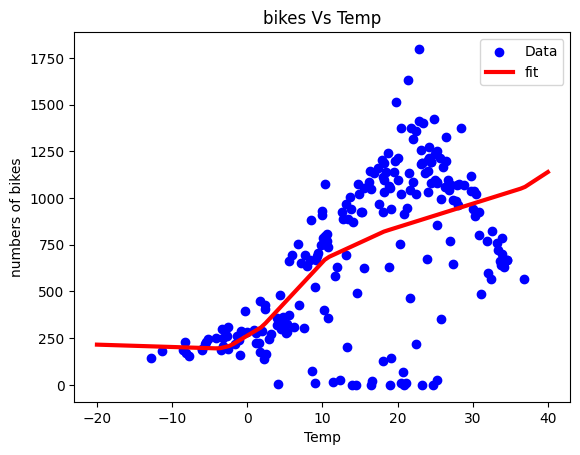

In [76]:
plt.scatter(x_train_temp, y_train_temp,label='Data', color='blue')
x= tf.linspace(-20, 40,100)
plt.plot(x, temp_nn_model.predict(np.array(x).reshape(-1,1)), label = 'fit', color ='red', linewidth = 3)
plt.legend()
plt.title('bikes Vs Temp')
plt.ylabel('numbers of bikes')
plt.xlabel('Temp')
plt.show()